In [1]:
file_path = "C:/Users/da3ma/OneDrive/Desktop/Internships/codealpha/Task 2/car data.csv"

In [2]:
#import tha libraries I need
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
#load the dataset
df = pd.read_csv(file_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
#check if theres missing value
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

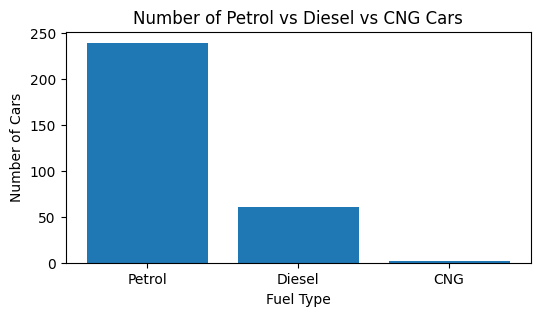

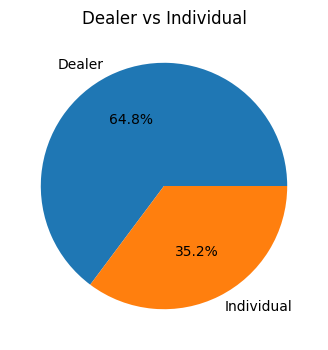

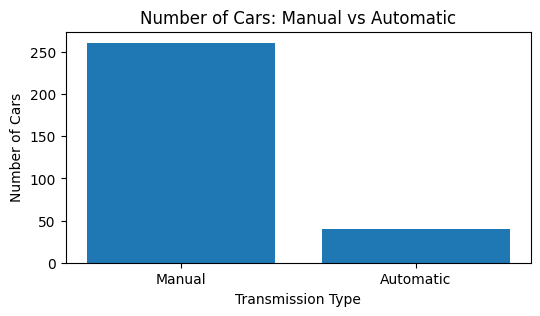

In [5]:
#bar chart for fuel type
fuel_counts = df['Fuel_Type'].value_counts()
plt.figure(figsize=(6,3))
plt.bar(fuel_counts.index, fuel_counts.values)
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Number of Petrol vs Diesel vs CNG Cars")
plt.show()

#pie chart for selling type
seller_counts = df['Selling_type'].value_counts()
plt.figure(figsize=(4,4))
plt.pie (seller_counts.values,
    labels=seller_counts.index,
    autopct='%1.1f%%')
plt.title("Dealer vs Individual")
plt.show()

#bar chart for transimssion
trans_counts = df['Transmission'].value_counts()
plt.figure(figsize=(6,3))
plt.bar(trans_counts.index, trans_counts.values)
plt.xlabel("Transmission Type")
plt.ylabel("Number of Cars")
plt.title("Number of Cars: Manual vs Automatic")
plt.show()

In [6]:
#use label encoder to convert Categorical to numbers
le = LabelEncoder()
df['Car_Name'] = le.fit_transform(df['Car_Name'])
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

In [7]:
#make a new column (car_age)  to turn year column into useful information
df['car_age'] = datetime.now().year - df['Year']

In [8]:
#drop year column
df.drop('Year', axis = 1 ,inplace=True)

In [9]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age
0,90,3.35,5.59,27000,2,0,1,0,12
1,93,4.75,9.54,43000,1,0,1,0,13
2,68,7.25,9.85,6900,2,0,1,0,9
3,96,2.85,4.15,5200,2,0,1,0,15
4,92,4.60,6.87,42450,1,0,1,0,12


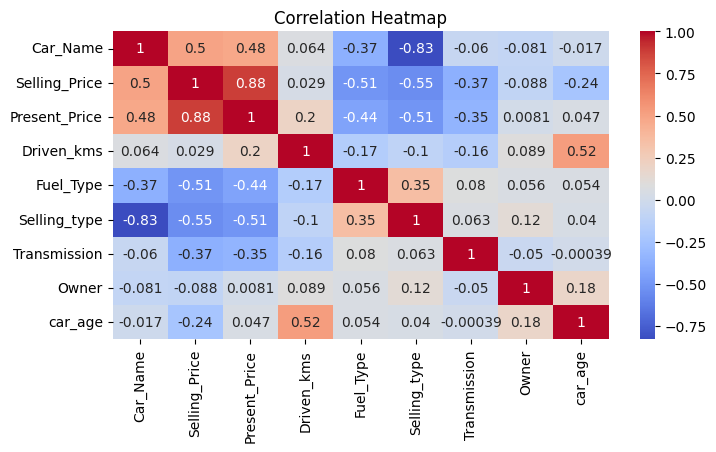

In [ ]:
#correlation matrix to see the relations between features
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [11]:
#select the featrues and the target
X = df.drop("Present_Price", axis=1)
y = df["Present_Price"]

In [12]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
#train the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
#make prediction for car prices
y_pred = model.predict(X_test)

In [16]:
y_pred = np.clip(y_pred, a_min=0, a_max=None)

In [17]:
#model evalution
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.9515188406159962
RMSE: 3.2078171470672765
R2 Score: 0.7959799624807231


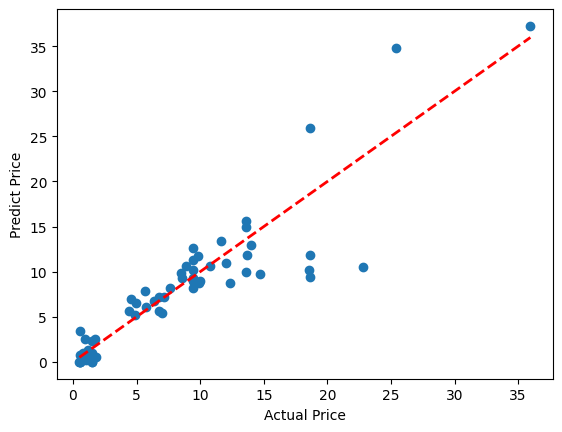

In [18]:
#visualization actual price VS predict price
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predict Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2) 
plt.show()